In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [4]:
import zipfile
import os

zip_file = "archive (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
os.listdir("dataset")

['email.csv']

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("dataset/email.csv")

In [8]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5573, 2)

In [10]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
df.isnull().sum()

,0
Category,0
Message,0


In [13]:
df['Category'].value_counts()

,count
Category,
ham,4825
spam,747
"{""mode"":""full""",1


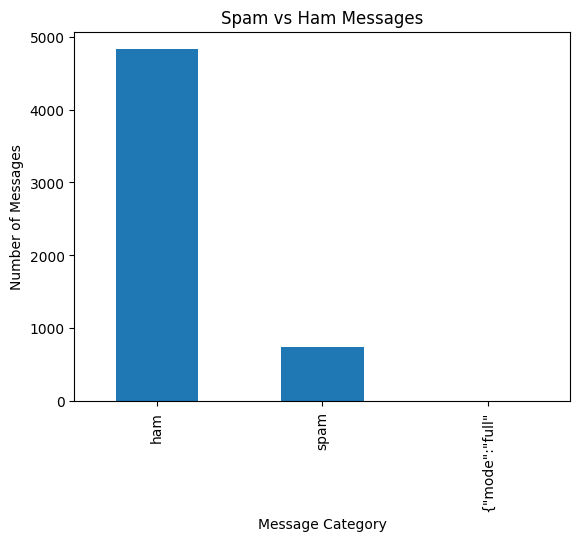

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Category'].value_counts().plot(kind='bar')

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Category')
plt.ylabel('Number of Messages')

plt.show()

In [15]:
df = df.dropna()

df['Message'] = df['Message'].astype(str)

df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

X = df['Message']
y = df['Category']

In [16]:
df['Category'].value_counts(dropna=False)

,count
Category,
0.0,4825
1.0,747
NaN,1


In [17]:
print("Missing Category values:", df['Category'].isna().sum())

Missing Category values: 1


In [18]:
df = df.dropna(subset=['Category'])

In [19]:
print(df['Category'].isna().sum())

0


In [20]:
X = df['Message']
y = df['Category']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

In [25]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [26]:
X_test_tfidf = vectorizer.transform(X_test)

In [27]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 7398)
Testing TF-IDF shape: (1115, 7398)


In [28]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

In [29]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [30]:
y_pred = model.predict(X_test_tfidf)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9695067264573991
Accuracy Percentage: 96.95067264573991 %


In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[966   0]
 [ 34 115]]


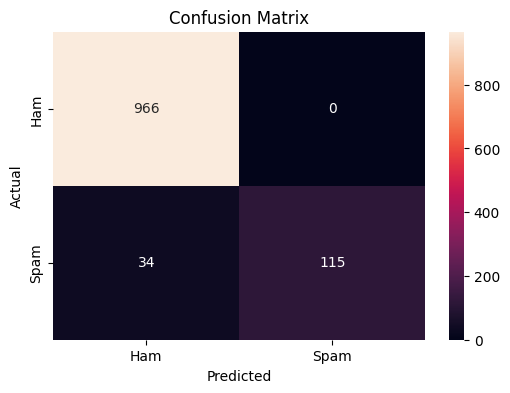

In [34]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [35]:
message = ["Congratulations! You have won a free lottery prize. Claim now!"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email


In [36]:
message = ["Hi, are we meeting tomorrow at 10 AM?"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


In [37]:
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)

    if prediction[0] == 1:
        return "Spam Email"
    else:
        return "Not Spam"

In [38]:
print(predict_spam("Congratulations! You won a free iPhone!"))

Not Spam


In [39]:
print(predict_spam("Please send me the project report tomorrow."))

Not Spam


In [40]:
print(predict_spam("URGENT! Claim your cash reward now!"))

Spam Email


In [41]:
test_messages = [
    "Congratulations! You have won a free iPhone!",
    "Hi, are we meeting tomorrow?",
    "URGENT! Claim your cash reward now!",
    "Please send me the project report.",
    "You have been selected for a lottery. Click here to claim your prize."
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_spam(message))
    print("-" * 60)

Message: Congratulations! You have won a free iPhone!
Prediction: Not Spam
------------------------------------------------------------
Message: Hi, are we meeting tomorrow?
Prediction: Not Spam
------------------------------------------------------------
Message: URGENT! Claim your cash reward now!
Prediction: Spam Email
------------------------------------------------------------
Message: Please send me the project report.
Prediction: Not Spam
------------------------------------------------------------
Message: You have been selected for a lottery. Click here to claim your prize.
Prediction: Spam Email
------------------------------------------------------------


In [42]:
def predict_spam_with_probability(message):
    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)
    probability = model.predict_proba(message_tfidf)

    spam_probability = probability[0][1] * 100
    ham_probability = probability[0][0] * 100

    if prediction[0] == 1:
        result = "Spam Email"
    else:
        result = "Not Spam"

    print("Message:", message)
    print("Prediction:", result)
    print("Spam Probability:", round(spam_probability, 2), "%")
    print("Not Spam Probability:", round(ham_probability, 2), "%")

In [43]:
predict_spam_with_probability(
    "Congratulations! You won a free lottery prize!"
)

Message: Congratulations! You won a free lottery prize!
Prediction: Spam Email
Spam Probability: 84.4 %
Not Spam Probability: 15.6 %


In [44]:
import joblib

In [45]:
joblib.dump(model, "spam_model.pkl")

['spam_model.pkl']

In [46]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [47]:
from google.colab import files

files.download("spam_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [50]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [51]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy Percentage:", svm_accuracy * 100, "%")

SVM Accuracy: 0.9820627802690582
SVM Accuracy Percentage: 98.20627802690582 %


In [66]:
print("SVM Classification Report")
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=['Ham', 'Spam']
    )
)

SVM Classification Report
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



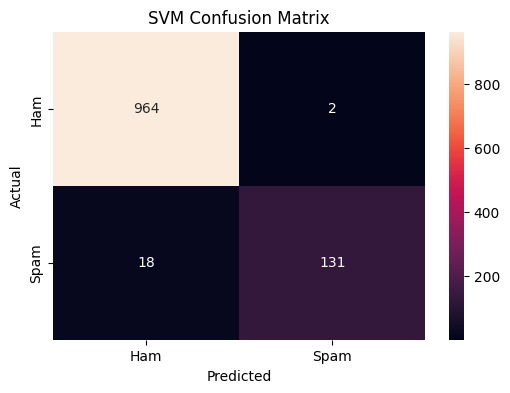

In [67]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')

plt.show()

In [68]:
def predict_spam_svm(message):
    message_tfidf = vectorizer.transform([message])
    prediction = svm_model.predict(message_tfidf)

    if prediction[0] == 1:
        return "Spam Email"
    else:
        return "Not Spam"

In [69]:
print(predict_spam_svm(
    "Congratulations! You have won a free iPhone!"
))

Not Spam


In [70]:
print(predict_spam_svm(
    "Hi, are we meeting tomorrow at 10 AM?"
))

Not Spam


In [71]:
print(predict_spam_svm(
    "URGENT! Claim your cash reward now!"
))

Spam Email


In [72]:
import joblib

joblib.dump(svm_model, "svm_spam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("SVM model and TF-IDF vectorizer saved successfully!")

SVM model and TF-IDF vectorizer saved successfully!


In [61]:
from google.colab import files

files.download("svm_spam_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
results = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results['Accuracy (%)'] = results['Accuracy'] * 100

results

,Model,Accuracy,Accuracy (%)
0,Multinomial Naive Bayes,0.969507,96.950673
1,Linear SVM,0.982063,98.206278


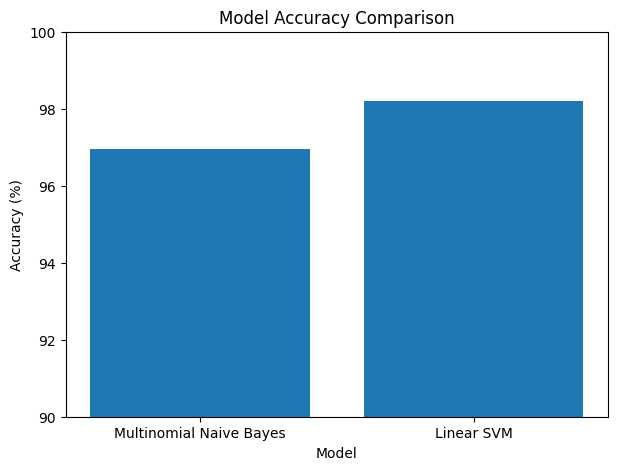

In [65]:
plt.figure(figsize=(7, 5))

plt.bar(
    results['Model'],
    results['Accuracy (%)']
)

plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.title('Model Accuracy Comparison')
plt.ylim(90, 100)

plt.show()

## Final Model

After comparing Multinomial Naive Bayes and Linear Support Vector Machine,
the Linear SVM model was selected as the final model.

The models achieved the following test accuracies:

- Multinomial Naive Bayes: 96.95%
- Linear SVM: 98.21%

Therefore, Linear SVM was selected because it achieved the higher test
accuracy on the given dataset.

## Project Workflow

1. Load the spam message dataset.
2. Clean the dataset and handle missing values.
3. Convert spam and ham labels into numerical values.
4. Split the dataset into training and testing sets.
5. Convert text into numerical features using TF-IDF.
6. Train a Multinomial Naive Bayes classifier.
7. Train a Linear SVM classifier.
8. Compare the performance of both models.
9. Evaluate the models using accuracy, precision, recall, F1-score and
   confusion matrix.
10. Select Linear SVM as the final model.
11. Test the final model using new messages.
12. Save the trained model and TF-IDF vectorizer.

## Model Performance

Two machine learning models were evaluated for spam classification:

- Multinomial Naive Bayes
- Linear Support Vector Machine (SVM)

The Multinomial Naive Bayes model achieved an accuracy of **96.95%**.

The Linear SVM model achieved an accuracy of **98.21%**.

Based on the test accuracy, Linear SVM performed better than Multinomial
Naive Bayes on this dataset.

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

## Conclusion

In this project, a machine learning based Spam Email Classifier was
developed using Natural Language Processing techniques.

The email messages were converted into numerical features using
TF-IDF vectorization.

Two machine learning algorithms were implemented and evaluated:

1. Multinomial Naive Bayes
2. Linear Support Vector Machine (SVM)

The Multinomial Naive Bayes model achieved an accuracy of 96.95%,
while the Linear SVM model achieved an accuracy of 98.21%.

Based on the test results, Linear SVM performed better on this dataset.

The project demonstrates how Natural Language Processing and Machine
Learning can be used to automatically classify messages as Spam or
Not Spam.

📧 Spam Email Classifier

1. Introduction
2. Import Libraries
3. Upload Dataset
4. Load Dataset
5. Dataset Exploration
6. Data Cleaning
7. Data Visualization
8. Label Encoding
9. Train-Test Split
10. TF-IDF Vectorization
11. Multinomial Naive Bayes
12. Naive Bayes Evaluation
13. Linear SVM
14. SVM Evaluation
15. Model Comparison
16. Custom Message Testing
17. Final Model
18. Save Model
19. Conclusion